In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [17]:
from variable_print import p,ps,pst

In [18]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

import numpy as np
import warnings
import random
from collections import deque
import time
from threading import Thread
from multiprocessing import cpu_count

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Asynchronous Advantage Actor-Critic(A3C)

## CartPole Discrete Environment

In [19]:
import gymnasium as gym
env_name = "CartPole-v1"
env = gym.make(env_name)
#env = gym.make("CartPole-v1",render_mode="rgb_array")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n
env.close()

# Actor  Network

In [21]:
hidden_size = 256

class Actor(nn.Module):
    def __init__(self, state_size, action_size):
        super(Actor, self).__init__()
        self.state_size = state_size
        self.action_size = action_size
        self.entropy_beta = 0.01  # 0.01~0.1

        self.model = nn.Sequential(
            nn.Linear(self.state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, self.action_size)
        )

    def forward(self, state):
        return self.model(state)

    def compute_loss(self, actions, logits, advantages):
        # 정책 손실 (Policy Loss)
        log_probs = F.log_softmax(logits, dim=-1)
        action_log_probs = log_probs.gather(1, actions)
        policy_loss = -(action_log_probs * advantages.detach()).mean()

        # 엔트로피 손실 (Entropy Loss)
        probs = F.softmax(logits, dim=-1)
        entropy = -(probs * log_probs).sum(dim=-1).mean()

        # 최종 손실
        return policy_loss - self.entropy_beta * entropy

#  Critic Network

In [22]:
class Critic(nn.Module):
    def __init__(self, state_size):
        super(Critic, self).__init__()
        self.state_size = state_size
        self.model = nn.Sequential(
            nn.Linear(self.state_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
        self.loss_fn = nn.MSELoss()
        # RMSprop optimizer를 모델 외부에 정의하여 global 모델의 파라미터를 최적화합니다.

    def forward(self, state):
        return self.model(state)

# Worker 스레드


In [23]:
class Worker(Thread):
    def __init__(self, id, env, gamma, global_actor, global_critic, global_actor_opt, global_critic_opt, lock):
        Thread.__init__(self)
        self.name = f"w{id}"
        self.env = env
        self.state_size = self.env.observation_space.shape[0]
        self.action_size = self.env.action_space.n
        self.gamma = gamma

        self.global_actor = global_actor
        self.global_critic = global_critic
        self.global_actor_opt = global_actor_opt
        self.global_critic_opt = global_critic_opt
        self.lock = lock  # 공유 Lock 참조

        self.actor = Actor(self.state_size, self.action_size)
        self.critic = Critic(self.state_size)
        self.sync_with_global()

    def sync_with_global(self):
        self.actor.load_state_dict(self.global_actor.state_dict())
        self.critic.load_state_dict(self.global_critic.state_dict())

    def get_action(self, state):
        state_tensor = torch.from_numpy(state).float().unsqueeze(0)
        with torch.no_grad():
            logits = self.actor(state_tensor)
            dist = Categorical(F.softmax(logits, dim=-1))
            action = dist.sample()
        return action.item()

    def n_step_td_target(self, rewards, next_V, done):
        td_targets = np.zeros_like(rewards)
        R_to_go = 0.0 if done else next_V
        for k in reversed(range(len(rewards))):
            R_to_go = rewards[k] + self.gamma * R_to_go
            td_targets[k] = R_to_go
        return td_targets

    def update_global(self, states_np, actions_np, rewards_np, next_state_np, done):
        states_tensor = torch.from_numpy(states_np).float()
        actions_tensor = torch.from_numpy(actions_np).long()

        # 로컬 네트워크로 Advantage 및 TD 타겟 계산
        with torch.no_grad():
            curr_V = self.critic(states_tensor)
            next_state_tensor = torch.from_numpy(next_state_np).float().unsqueeze(0)
            next_V = self.critic(next_state_tensor).numpy()[0, 0]

        td_targets_np = self.n_step_td_target(rewards_np, next_V, done)
        advantages_np = td_targets_np - curr_V.numpy()
        td_targets_tensor = torch.from_numpy(td_targets_np).float()
        advantages_tensor = torch.from_numpy(advantages_np).float()

        # 로컬 네트워크에서 손실 및 그래디언트 계산
        logits = self.actor(states_tensor)
        v_pred = self.critic(states_tensor)
        actor_loss = self.actor.compute_loss(actions_tensor, logits, advantages_tensor)
        critic_loss = self.critic.loss_fn(v_pred, td_targets_tensor)
        total_loss = actor_loss + critic_loss
        total_loss.backward()

        # --- 임계 영역: Lock으로 보호 ---
        self.lock.acquire()
        try:
            # 로컬 그래디언트를 전역 모델로 복사
            for local_param, global_param in zip(self.actor.parameters(), self.global_actor.parameters()):
                global_param.grad = local_param.grad
            for local_param, global_param in zip(self.critic.parameters(), self.global_critic.parameters()):
                global_param.grad = local_param.grad

            # 전역 모델 파라미터 업데이트
            self.global_actor_opt.step()
            self.global_critic_opt.step()

        finally:
            self.lock.release()
        # --- 임계 영역 종료 ---

        # 로컬 그래디언트 초기화 및 전역 모델과 동기화
        self.actor.zero_grad()
        self.critic.zero_grad()
        self.sync_with_global()

    def run(self):
        global GLOBAL_EP
        while max_episodes > GLOBAL_EP:
            tot_reward = 0
            state, _ = self.env.reset()
            states, actions, rewards = [], [], []
            done = False
            start_time = time.time()

            while not done and tot_reward < 500 :
                action = self.get_action(state)
                next_state, reward, done, _, _ = self.env.step(action)
                states.append(state)
                actions.append([action])
                rewards.append([reward])
                state = next_state
                tot_reward += reward

                if len(states) >= update_interval or done:
                    states_np, actions_np, rewards_np = np.vstack(states), np.vstack(actions), np.vstack(rewards)
                    self.update_global(states_np, actions_np, rewards_np, next_state, done)
                    states, actions, rewards = [], [], []

            episode_reward.append(tot_reward)
            end_time = time.time()
            print(f'{self.name} | EP{GLOBAL_EP + 1} EpisodeReward={tot_reward:.1f} ({end_time - start_time:.1f}s)')
            GLOBAL_EP += 1



# A3C Agent

In [24]:
from threading import Lock # Import Lock

class A3CAgent:
    def __init__(self, env_name, gamma):
        env = gym.make(env_name)
        self.state_size = env.observation_space.shape[0]
        self.action_size = env.action_space.n
        self.gamma = gamma

        self.global_actor = Actor(self.state_size, self.action_size)
        self.global_critic = Critic(self.state_size)
        self.global_actor_opt = optim.RMSprop(self.global_actor.parameters(), lr=actor_lr)
        self.global_critic_opt = optim.RMSprop(self.global_critic.parameters(), lr=critic_lr)

        self.lock = Lock()  # Lock 객체 생성
        self.num_workers = cpu_count()

    def train(self):
        print(f"Training on {self.num_workers} cores")
        workers = [Worker(i, gym.make(env_name), self.gamma, self.global_actor, self.global_critic,
                          self.global_actor_opt, self.global_critic_opt, self.lock)
                   for i in range(self.num_workers)]
        for worker in workers:
            worker.start()
        for worker in workers:
            worker.join()

    def get_action(self, state):
        # Use the global actor to get an action for visualization
        state_tensor = torch.from_numpy(state).float().unsqueeze(0)
        with torch.no_grad():
            logits = self.global_actor(state_tensor)
            dist = Categorical(F.softmax(logits, dim=-1))
            action = dist.sample()
        return action.item()

# Training

In [25]:
import os

def set_seed(seed: int = 42) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [26]:
%%time
set_seed()
#env_name = "CartPole-v1"

# 환경 설정
actor_lr = 0.0001
critic_lr = 0.001
gamma = 0.99
hidden_size = 256
update_interval = 16

GLOBAL_EP = 0
max_episodes = 400
episode_reward = []

agent = A3CAgent(env_name, gamma)
agent.train()

# agent.save_model()
## Wall time: 36.3 s @300

Training on 12 cores
w0 | EP1 EpisodeReward=13.0 (0.2s)
w4 | EP2 EpisodeReward=16.0 (0.3s)
w10 | EP3 EpisodeReward=16.0 (0.3s)
w7 | EP4 EpisodeReward=19.0 (0.3s)
w2 | EP5 EpisodeReward=27.0 (0.4s)
w5 | EP6 EpisodeReward=24.0 (0.4s)
w4 | EP7 EpisodeReward=10.0 (0.2s)
w10 | EP8 EpisodeReward=15.0 (0.2s)
w0 | EP9 EpisodeReward=21.0 (0.3s)
w11 | EP10 EpisodeReward=32.0 (0.5s)
w3 | EP11 EpisodeReward=38.0 (0.5s)
w4 | EP12 EpisodeReward=12.0 (0.2s)
w10 | EP13 EpisodeReward=15.0 (0.2s)
w6 | EP14 EpisodeReward=34.0 (0.6s)
w9 | EP15 EpisodeReward=45.0 (0.7s)
w7 | EP16 EpisodeReward=20.0 (0.4s)
w11 | EP17 EpisodeReward=13.0 (0.2s)
w4 | EP18 EpisodeReward=12.0 (0.2s)
w5 | EP19 EpisodeReward=28.0 (0.4s)
w10 | EP20 EpisodeReward=12.0 (0.2s)
w3 | EP21 EpisodeReward=21.0 (0.3s)
w1 | EP22 EpisodeReward=73.0 (0.9s)
w6 | EP23 EpisodeReward=25.0 (0.4s)
w10 | EP24 EpisodeReward=14.0 (0.2s)
w9 | EP25 EpisodeReward=23.0 (0.4s)
w2 | EP26 EpisodeReward=50.0 (0.7s)
w11 | EP27 EpisodeReward=26.0 (0.4s)
w4 | EP2

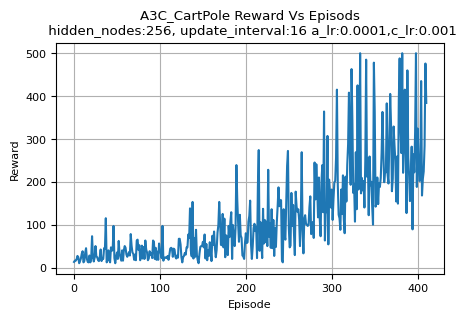

In [27]:
conditions = f'hidden_nodes:{hidden_size}, update_interval:{update_interval} \
a_lr:{actor_lr},c_lr:{critic_lr}'

# 학습 결과 시각화
plt.figure(figsize=(5, 3))
plt.plot(episode_reward)
plt.title(f"A3C_CartPole Reward Vs Episods\n {conditions}")
plt.ylabel("Reward")
plt.xlabel("Episode")
plt.grid()
plt.show()

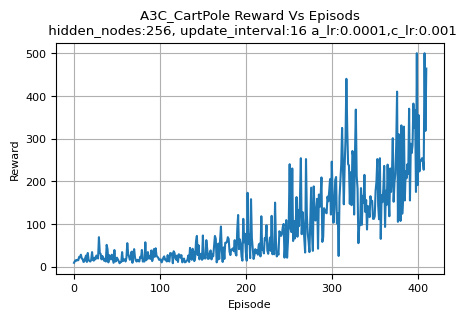

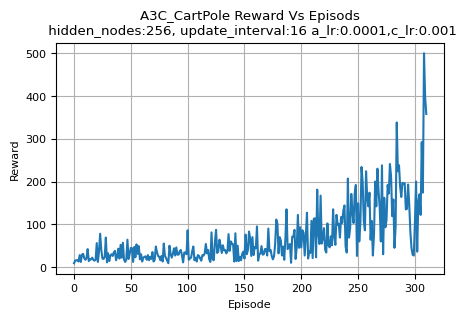

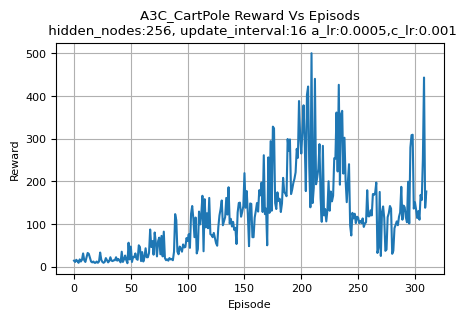

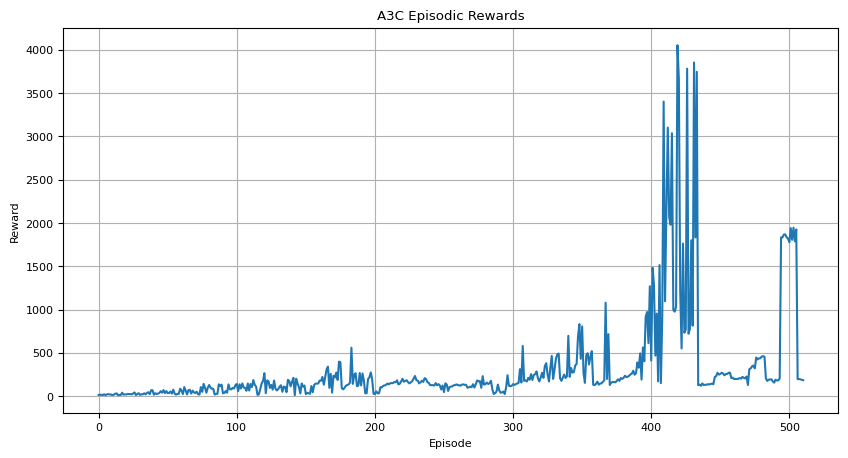

201.0


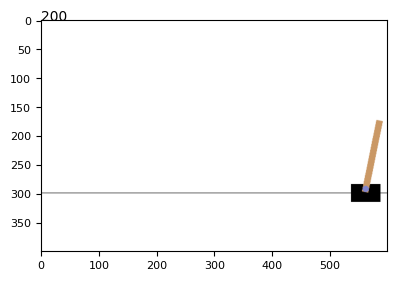

In [29]:
from IPython.display import clear_output

env = gym.make("CartPole-v1",render_mode="rgb_array")

state,_ = env.reset()
action_l = []
rewards = 0
plt.figure(figsize=(5,3))
for i in range(500): # while True:
    plt.imshow(env.render())
    plt.text(0,0,str(i),fontsize=10)
    action = agent.get_action(state)
    state, reward, done , info, _ = env.step(action)
    clear_output(wait=True)
    rewards += reward
    if done: break;
    else: plt.show()
print(rewards)
env.close()